$$
\text{时间序列模型 (ARIMA)} \\
\text{自回归模型 (AR)} \\
\text{移动平均模型 (MA)} \\
\text{差分 (I)} \\
\text{也叫做 差分整合移动平均自回归模型} \\
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, pacf

# 完整 38 行数据
data_list = np.array([
    ('2014-1-2',  2.62, 2.62, 2.59, 2.61, 41632500),
    ('2014-1-3',  2.6,  2.61, 2.56, 2.56, 45517700),
    ('2014-1-6',  2.57, 2.57, 2.5,  2.53, 68674700),
    ('2014-1-7',  2.51, 2.52, 2.49, 2.52, 53293800),
    ('2014-1-8',  2.51, 2.54, 2.49, 2.51, 69087900),
    ('2014-1-9',  2.51, 2.53, 2.49, 2.5,  45339800),
    ('2014-1-10', 2.5,  2.51, 2.49, 2.49, 41009000),
    ('2014-1-13', 2.5,  2.52, 2.5,  2.52, 29469300),
    ('2014-1-14', 2.51, 2.52, 2.5,  2.51, 30626300),
    ('2014-1-15', 2.51, 2.52, 2.5,  2.51, 50614100),
    ('2014-1-16', 2.51, 2.52, 2.49, 2.5,  31381500),
    ('2014-1-17', 2.5,  2.5,  2.48, 2.48, 41326400),
    ('2014-1-20', 2.49, 2.49, 2.45, 2.47, 39797800),
    ('2014-1-21', 2.46, 2.48, 2.46, 2.47, 33143500),
    ('2014-1-22', 2.47, 2.51, 2.47, 2.51, 52102900),
    ('2014-1-23', 2.5,  2.5,  2.48, 2.48, 40174200),
    ('2014-1-24', 2.48, 2.5,  2.47, 2.49, 36289700),
    ('2014-1-27', 2.48, 2.49, 2.46, 2.48, 43715200),
    ('2014-1-28', 2.48, 2.5,  2.47, 2.49, 29807200),
    ('2014-1-29', 2.5,  2.53, 2.49, 2.53, 39061000),
    ('2014-1-30', 2.52, 2.53, 2.51, 2.51, 19595700),
    ('2014-1-31', 2.51, 2.51, 2.51, 2.51, 0),
    ('2014-2-3',  2.51, 2.51, 2.51, 2.51, 0),
    ('2014-2-5',  2.51, 2.51, 2.51, 2.51, 0),
    ('2014-2-6',  2.51, 2.51, 2.51, 2.51, 0),
    ('2014-2-7',  2.5,  2.5,  2.48, 2.49, 21622600),
    ('2014-2-10', 2.5,  2.52, 2.49, 2.51, 36473700),
    ('2014-2-11', 2.51, 2.56, 2.5,  2.55, 60653200),
    ('2014-2-12', 2.54, 2.56, 2.53, 2.54, 29736800),
    ('2014-2-13', 2.54, 2.57, 2.53, 2.55, 48498800),
    ('2014-2-14', 2.55, 2.55, 2.53, 2.54, 27342300),
    ('2014-2-17', 2.54, 2.56, 2.54, 2.55, 31423800),
    ('2014-2-18', 2.55, 2.56, 2.53, 2.54, 30007000),
    ('2014-2-19', 2.54, 2.67, 2.53, 2.63, 106000000),
    ('2014-2-20', 2.62, 2.64, 2.6,  2.61, 45629300),
    ('2014-2-21', 2.6,  2.61, 2.56, 2.58, 27924300),
    ('2014-2-24', 2.57, 2.58, 2.51, 2.53, 29814500),
    ('2014-2-25', 2.53, 2.55, 2.51, 2.54, 34158800)
])

# 转换为 numpy 数组
data = data_list[:, 4].astype(float)
data

array([2.61, 2.56, 2.53, 2.52, 2.51, 2.5 , 2.49, 2.52, 2.51, 2.51, 2.5 ,
       2.48, 2.47, 2.47, 2.51, 2.48, 2.49, 2.48, 2.49, 2.53, 2.51, 2.51,
       2.51, 2.51, 2.51, 2.49, 2.51, 2.55, 2.54, 2.55, 2.54, 2.55, 2.54,
       2.63, 2.61, 2.58, 2.53, 2.54])

$$
\text{自回归模型 (AR)} \\ \quad \\
\text{描述当前值和历史值之间的关系，用变量自身的历史数据对自身进行预测} \\
\text{其必须要满足平稳性要求，只适用于预测与自身前期相关的现象} \\
\text{p 阶自回归过程的公式定义: } \\
y_t = \mu + \sum_{i=0}^{p-1} \gamma_i y_{t-i} + \epsilon_t \\
p\text{: 表示用几期的历史值来预测 或者 阶数} \\
y_t\text{: 表示当前期的预测值} \\
\mu\text{: 表示常数项} \\
\gamma_i\text{: 表示自相关系数} \\
\epsilon_t\text{: 表示随机误差项} \\
$$

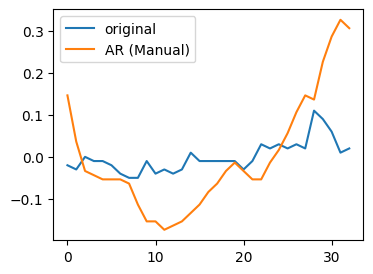

In [19]:
p = 5
gamma = np.array([1] * p)

# 严格意义上的“自回归式”计算：用前 5 个点计算当前点
data_AR = []
for i in range(p, len(data)):
    # 取当前位置之前的 p 个点：data[i-p : i]
    # 注意：AR 模型的系数通常是反向对应的，即 gamma[0] 对应 t-1
    past_values = data[i-p : i][::-1] 
    current_val = np.dot(gamma, past_values)
    data_AR.append(current_val)

# 绘图时注意：data_AR 比原数据少前 p 个点
plt.figure(figsize=(4, 3))
plt.plot(data[p:] - data[p:].mean(), label='original')
plt.plot(data_AR - np.mean(data_AR), label='AR (Manual)')
plt.legend()

$$
\text{移动平均模型 (MA)} \\ \quad \\
\text{描述当前值和历史误差项之间的关系，用随机误差项的历史数据对自身进行预测} \\
\text{q 阶移动平均过程的公式定义: } \\
y_t = \mu + \sum_{i=1}^q \theta_i \epsilon_{t-i} + \epsilon_t \\
\text{即时间序列当前值与历史值没有关系，而只依赖于历史白噪声的线性组合} \\
\text{移动平均法能有效地消除预测中的随机波动} \\ \quad \\
q\text{: 表示用几期的历史误差项来预测 或者 阶数} \\
y_t\text{: 表示当前期的预测值} \\
\mu\text{: 表示常数项} \\
\theta_i\text{: 表示移动平均系数} \\
\epsilon_t\text{: 表示随机误差项} \\
$$

$$
\text{自回归移动平均模型 (ARMA)} \\ \quad \\
\text{自回归与移动平均的结合} \\
\text{ARMA(p, q) 模型的公式定义: } \\
y_t = \mu + \sum_{i=1}^p \gamma_i y_{t-i} + \sum_{i=1}^q \theta_i \epsilon_{t-i} + \epsilon_t \\
p\text{: 表示用几期的历史值来预测 或者 阶数} \\
q\text{: 表示用几期的历史误差项来预测 或者 阶数} \\
y_t\text{: 表示当前期的预测值} \\
\mu\text{: 表示常数项} \\
\gamma_i\text{: 表示自相关系数} \\
\theta_i\text{: 表示移动平均系数} \\
\epsilon_t\text{: 表示随机误差项} \\
$$

$$
\text{差分自回归移动平均模型 (ARIMA)} \\ \quad \\
\text{将自回归模型 (AR), 移动平均模型 (MA) 和差分法结合, 我们就得到了差分自回归移动平均模型} \\
\text{ARIMA 模型的公式定义: } \\
y_t = \mu + \sum_{i=1}^p \gamma_i y_{t-i} + \sum_{i=1}^q \theta_i \epsilon_{t-i} + \epsilon_t \\
p\text{: 表示用几期的历史值来预测 或者 阶数} \\
q\text{: 表示用几期的历史误差项来预测 或者 阶数} \\
y_t\text{: 表示当前期的预测值} \\
\mu\text{: 表示常数项} \\
\gamma_i\text{: 表示自相关系数} \\
\theta_i\text{: 表示移动平均系数} \\
\epsilon_t\text{: 表示随机误差项} \\
$$

$$
\text{平稳性} \\
\text{平稳性就是要求经由样本时间序列所得到的拟合曲线在未来的一段时间内仍然能够按照现有的形态延续下去} \\
\text{平稳性要求序列的均值和方差不发生明显变化} \\
\text{严平稳性: 序列的所有统计性质(期望，方差) 都不会随着时间的推移而发生变化} \\
\text{宽平稳性: 期望与相关系数(依赖性) 不变，就是说t时刻的值X依赖于过去的信息} \\
\text{实际数据大致上都是宽平稳，平稳性对于分析时间序列至关重要。} \\
\text{如果一个时间序列不是平稳的，通常需要通过差分的方式将其转化为平稳时间序列} \\
$$

$$
\text{差分法} \\
\text{差分法是一种常用的将非平稳时间序列转换为平稳时间序列的方法} \\
\text{差分法的基本思想是: 用当前期的值减去前一期的值, 得到的差值序列就是平稳序列} \\
\text{差分法的阶数: 表示用几期的历史值来预测当前期的值} \\
\text{差分法的公式定义: } \\
\Delta yx = y(x+1) - y(x), \quad (x=0, 1, 2, ...) \\
y(x)\text{: 表示当前期的预测值} \\
y(x+1)\text{: 表示后一期的预测值} \\
\text{比如一组数列: } \\
y = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10] \\
\text{差分后: } \\
\Delta y = [1, 1, 1, 1, 1, 1, 1, 1, 1] \\
$$

$$
\text{自相关系数 (ACF)} \\
ACF(k) = \rho_k = \frac{\text{COV}(y_t, y_{t-k})}{\text{var}(y_t)} \text{ 取值范围为} [-1, 1] \\ \quad \\
\text{偏自相关系数 (PACF)} \\
PACF(k) = \frac{\text{COV}[(y_t - \bar{y}_t), (y_{t-k} - \bar{y}_{t-k})]}{\sqrt{\text{var}(y_t - \bar{y}_t)} \sqrt{\text{var}(y_{t-k} - \bar{y}_{t-k})}} $$

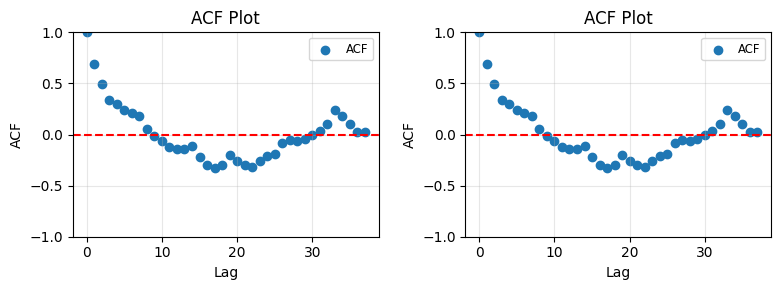

In [ ]:
def plot_nicely():
    for ax in plt.gcf().get_axes():
        ax.grid(True, which="both", alpha=0.3)
        ax.legend(fontsize='small')
    plt.tight_layout()

def calc_acf_all(y, max_lag):
    y_centered = y - np.mean(y)
    # 使用快速卷积/相关函数计算
    n = len(y)
    # correlate 返回所有可能的重叠结果，我们只取中间重叠的部分
    acov = np.correlate(y_centered, y_centered, mode='full')[n-1 : n+max_lag]
    return acov / acov[0] # 除以第0项（方差）即得到所有 ACF

acfs = calc_acf_all(data, max_lag=len(data)-1)
fig, axs = plt.subplots(1, 2, figsize=(8, 3))
axs[0].scatter(range(len(acfs)), acfs, label='ACF')
axs[0].axhline(0, color='r', linestyle='--')
axs[0].set_title("ACF Plot")
axs[0].set_ylim(-1, 1)
axs[0].set_xlabel("Lag")
axs[0].set_ylabel("ACF")

axs[1].scatter(range(len(data)), acf(data, nlags=len(data)-1), label='ACF')
axs[1].axhline(0, color='r', linestyle='--')
axs[1].set_title("ACF Plot")
axs[1].set_ylim(-1, 1)
axs[1].set_xlabel("Lag")
axs[1].set_ylabel("ACF")

plot_nicely()


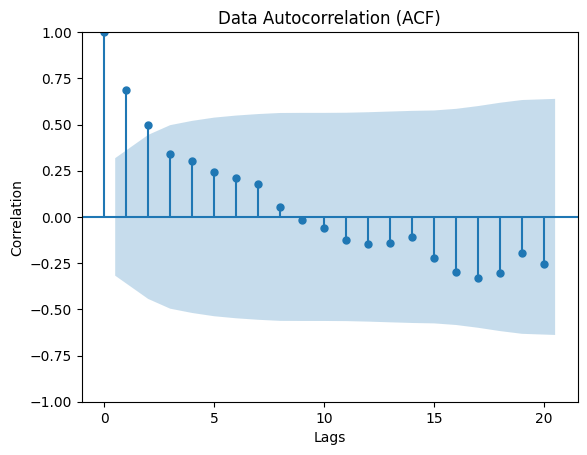

In [ ]:
plot_acf(data, lags=20)
plt.title("Data Autocorrelation (ACF)")
plt.xlabel("Lags")
plt.ylabel("Correlation")
plt.show()

$$
\text{ADF 检验} \\
$$